# RCD funcs

In [68]:
import os
import sys

path_add = r"C:\Users\GreenBird\Documents\GitHub\ColibriPipeline\ColibriPipeline"
if path_add not in sys.path:
    sys.path.append(path_add)

import ColibriPipeline.colibri_image_reader as cir

# Testing coincidence checking

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt

green_archive = r"D:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19"
blue_archive = r"B:\LongTermStorage\PipelineTesting\ColibriArchive\2024-10-19"
# red_archive = r"R:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19"

# Find all the files in each directory that begin with "det" and end with ".txt"
green_files = [f for f in os.listdir(green_archive) if f.startswith("det") and f.endswith(".txt")]
blue_files = [f for f in os.listdir(blue_archive) if f.startswith("det") and f.endswith(".txt")]
# red_files = [f for f in os.listdir(red_archive) if f.startswith("det") and f.endswith(".txt")]

# print the first green file just to check
print(green_files[0])

det_2024-10-19_235117_561239000_star45_GREENBIRD.txt


In [89]:
from datetime import datetime, timedelta

# Example of extracting and printing the time part
time_part_example = green_files[0].split("_")[2:4]  # first part is HHMMSS, second part is fraction of seconds
print(time_part_example)

# For every file, read the time parts, create tuples for files in green and blue that occur in the same time within 0.1 seconds
coincident_detections = []  # list of tuples (green_file, blue_file)
for green_file in green_files:
    # Extract the time part from the filename
    time_part = green_file.split("_")[2:4]  # first part is HHMMSS, second part is fraction of seconds
    time_str = time_part[0] + "." + time_part[1][:6]  # combine HHMMSS and first 6 digits of fraction of seconds
    green_time = datetime.strptime(time_str, "%H%M%S.%f")  # convert to datetime object

    # Find the corresponding blue file with the same time part
    for blue_file in blue_files:
        blue_time_part = blue_file.split("_")[2:4]
        blue_time_str = blue_time_part[0] + "." + blue_time_part[1][:6]  # truncate to 6 digits
        blue_time = datetime.strptime(blue_time_str, "%H%M%S.%f")  # convert to datetime object

        # Compare the times with a tolerance of 0.1 seconds
        if abs((green_time - blue_time).total_seconds()) < 0.1:
            coincident_detections.append((green_file, blue_file))

print(f"Number of green files: {len(green_files)}")
print(f"Number of blue files: {len(blue_files)}")
print(f"Number of coincident detections: {len(coincident_detections)}")

['235117', '561239000']
Number of green files: 933
Number of blue files: 741
Number of coincident detections: 1


Green file: det_2024-10-20_044119_306711000_star0_GREENBIRD.txt
Blue file: det_2024-10-20_044119_379544000_star35_BLUEBIRD.txt


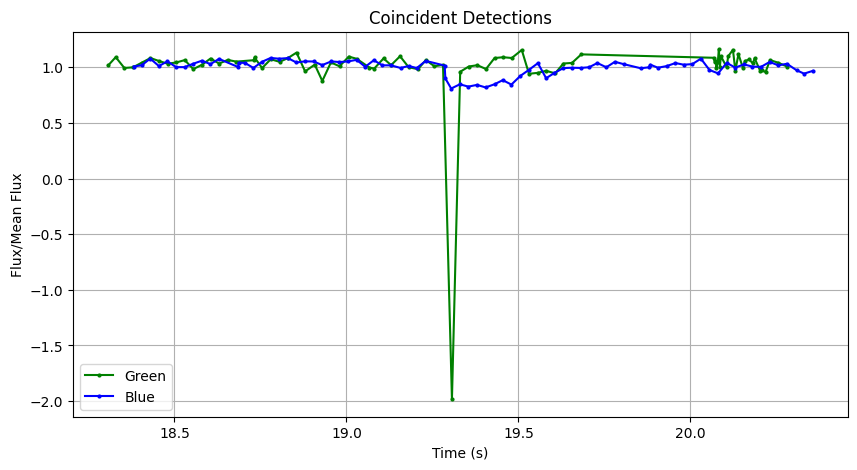

In [90]:
import pandas as pd




# Read the data from the files and plot the data

# df = pd.read_csv(os.path.join(data_loc, f), delim_whitespace=True, skiprows=lambda x: x< 19, names=['filename', 'time', 'flux', 'conv_flux'])

detect_idx = 0
data_green = pd.read_csv(os.path.join(green_archive, coincident_detections[detect_idx][0]), delim_whitespace=True, skiprows=lambda x: x< 19, names=['filename', 'time', 'flux', 'conv_flux'])
data_blue = pd.read_csv(os.path.join(blue_archive, coincident_detections[detect_idx][1]), delim_whitespace=True, skiprows=lambda x: x< 19, names=['filename', 'time', 'flux', 'conv_flux'])

# print the filenames
print(f"Green file: {coincident_detections[detect_idx][0]}")
print(f"Blue file: {coincident_detections[detect_idx][1]}")

# plot the data 
plt.figure(figsize=(10, 5))
plt.plot(data_green['time'], data_green['flux']/np.mean(data_green['flux']), label='Green', color='green', marker='o', markersize=2)
plt.plot(data_blue['time'], data_blue['flux']/np.mean(data_blue['flux']), label='Blue', color='blue', marker='o', markersize=2)
plt.xlabel('Time (s)')
plt.ylabel('Flux/Mean Flux')
plt.title('Coincident Detections')
plt.legend()
plt.grid()
plt.show()


Number of green detection filepaths: 80


C:\Users\GreenBird\AppData\Local\Temp\ipykernel_15328\414936534.py:13: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(rcd_files[0]), cmap='gray')
C:\Users\GreenBird\AppData\Local\Temp\ipykernel_15328\414936534.py:18: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(rcd_files[-1]), cmap='gray')


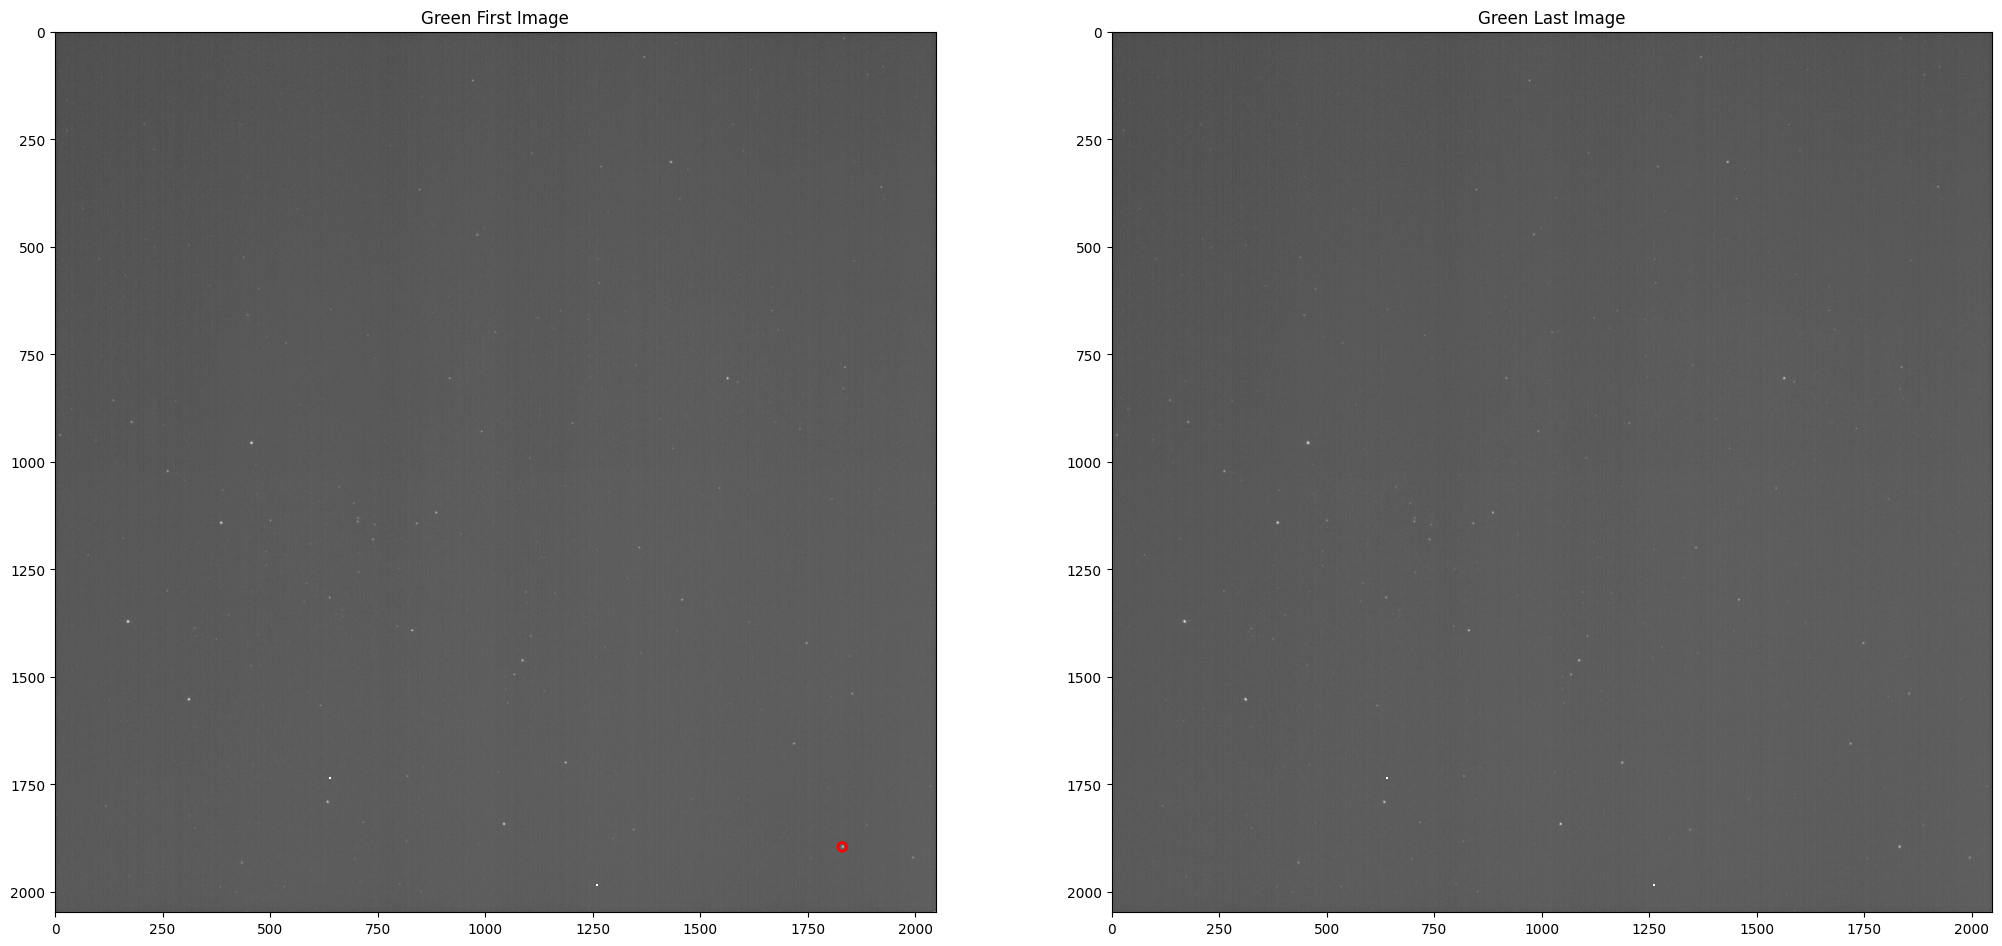

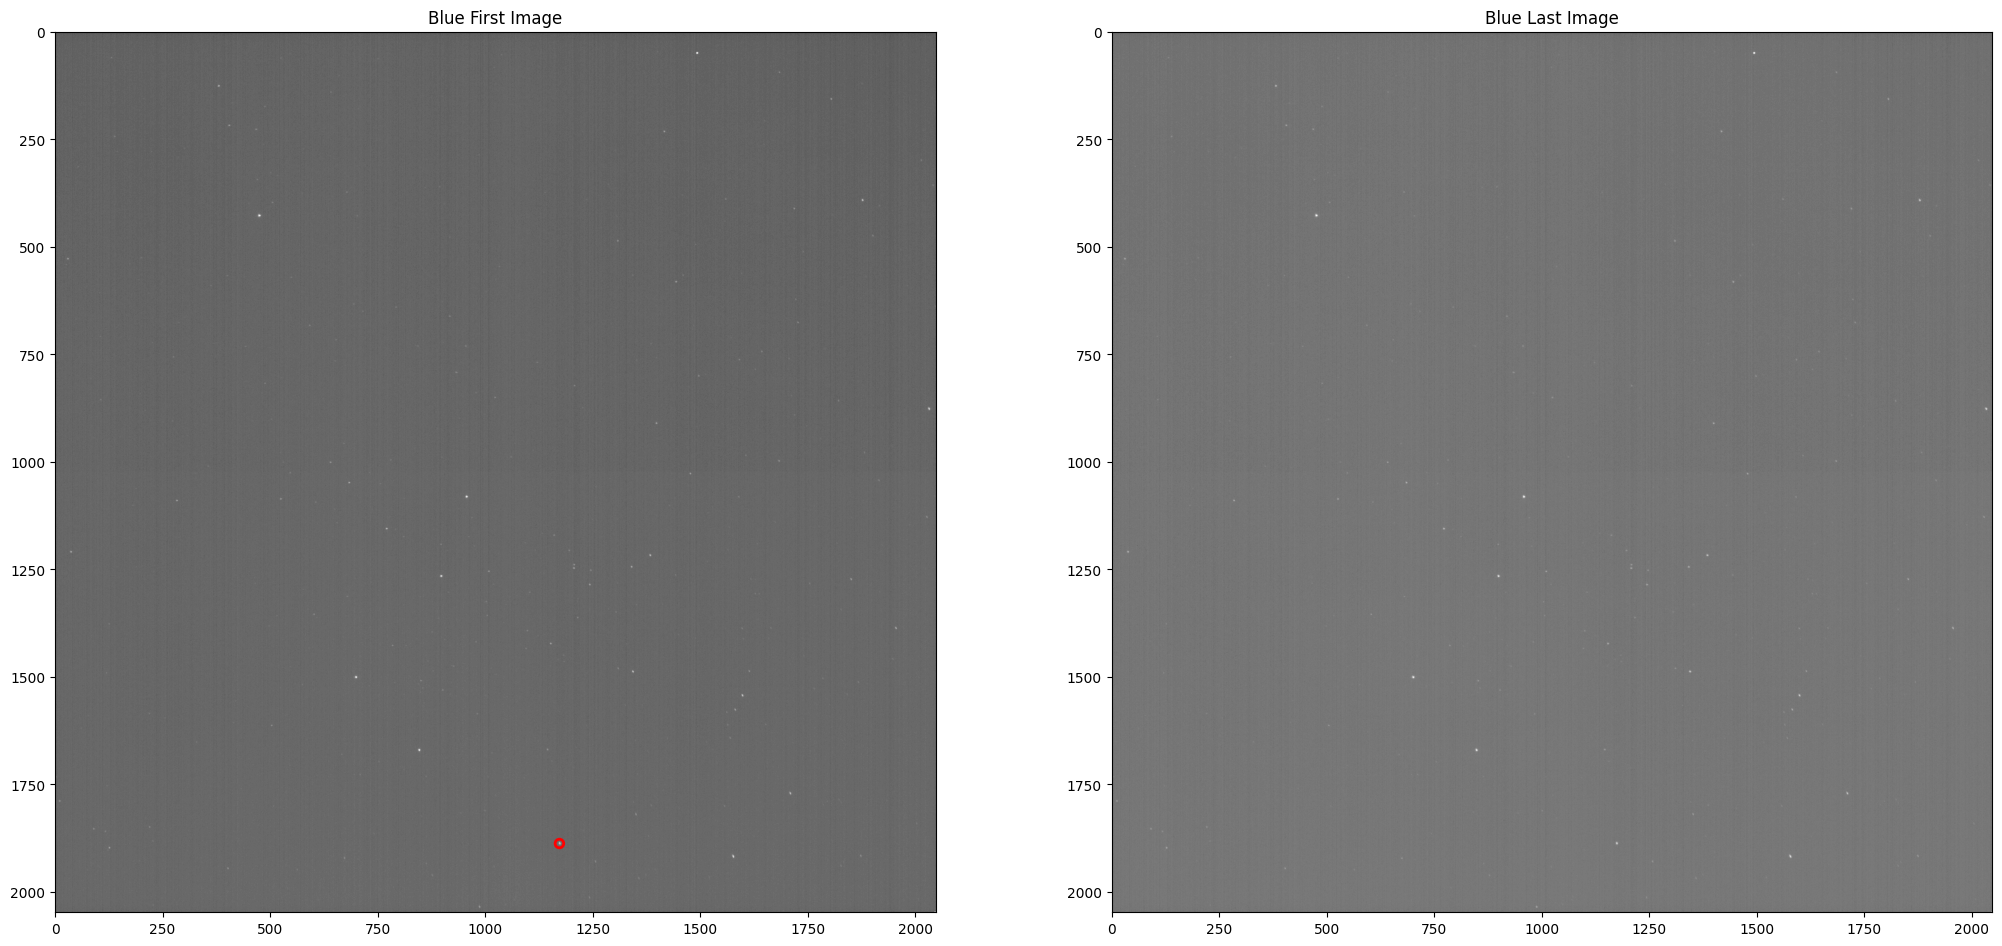

In [88]:
green_detection_filepaths = data_green['filename'].values
len_paths = len(green_detection_filepaths)
print(f"Number of green detection filepaths: {len_paths}")

rcd_files = cir.importFramesRCD(green_detection_filepaths,0, 80)[0]

star_coords_green = 1830.921818, 1895.432010 # x y coordinates of the star in the image
star_coords_blue = 1172.875961, 1887.601939

# Plot the first and last images in the list
plt.figure(figsize=(25, 20))
plt.subplot(1, 2, 1)
plt.imshow(np.log(rcd_files[0]), cmap='gray')
# Plot a circle over the x y coordinates of the star
plt.gca().add_patch(plt.Circle(star_coords_green, 10, color='red', fill=False, linewidth=2))
plt.title('Green First Image')
plt.subplot(1, 2, 2)
plt.imshow(np.log(rcd_files[-1]), cmap='gray')
plt.title('Green Last Image')
plt.show()

# do exactly the same for the blue images
blue_detection_filepaths = data_blue['filename'].values
# replace D: with B: in the filepaths
blue_detection_filepaths = [f.replace('D:', 'B:') for f in blue_detection_filepaths]
rcd_files_blue = cir.importFramesRCD(blue_detection_filepaths,0, 80)[0]



# Plot the first and last images in the list
plt.figure(figsize=(25, 20))
plt.subplot(1, 2, 1)
plt.imshow(np.log(rcd_files_blue[0]), cmap='gray')
# Plot a circle over the x y coordinates of the star
plt.gca().add_patch(plt.Circle(star_coords_blue, 10, color='red', fill=False, linewidth=2))
plt.title('Blue First Image')
plt.subplot(1, 2, 2)
plt.imshow(np.log(rcd_files_blue[-1]), cmap='gray')
plt.title('Blue Last Image')
plt.show()

# Individual Lightcurves

In [ ]:
npy_file = r"D:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19\20241020_02.12.30.710_stars.npy"

# read the npy file
import numpy as np
import os
import matplotlib.pyplot as plt

data = np.load(npy_file, allow_pickle=True)
print(data.shape)

[1.72939035e+09 1.72939035e+09 1.72939035e+09 ... 1.72939041e+09
 1.72939041e+09 1.72939041e+09]


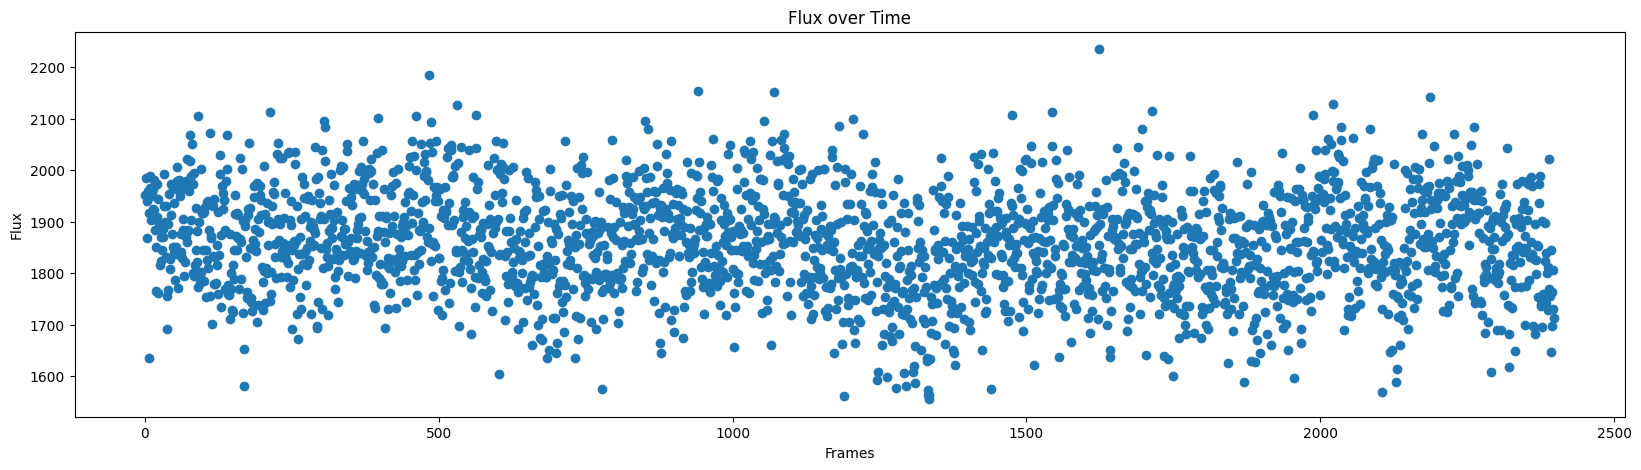

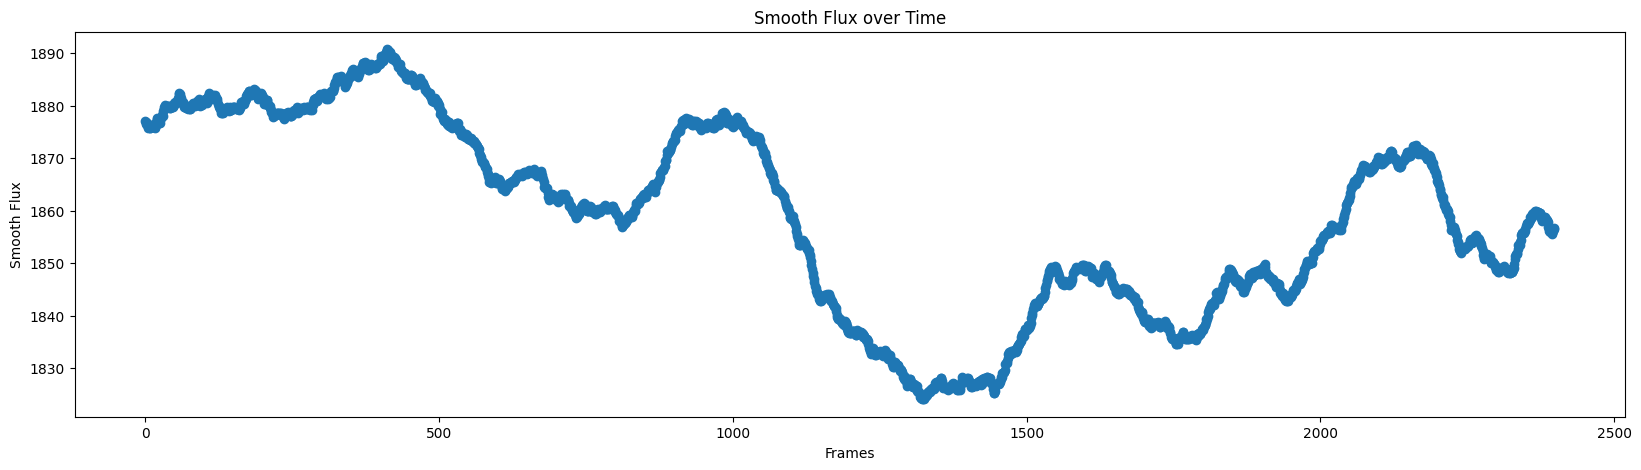

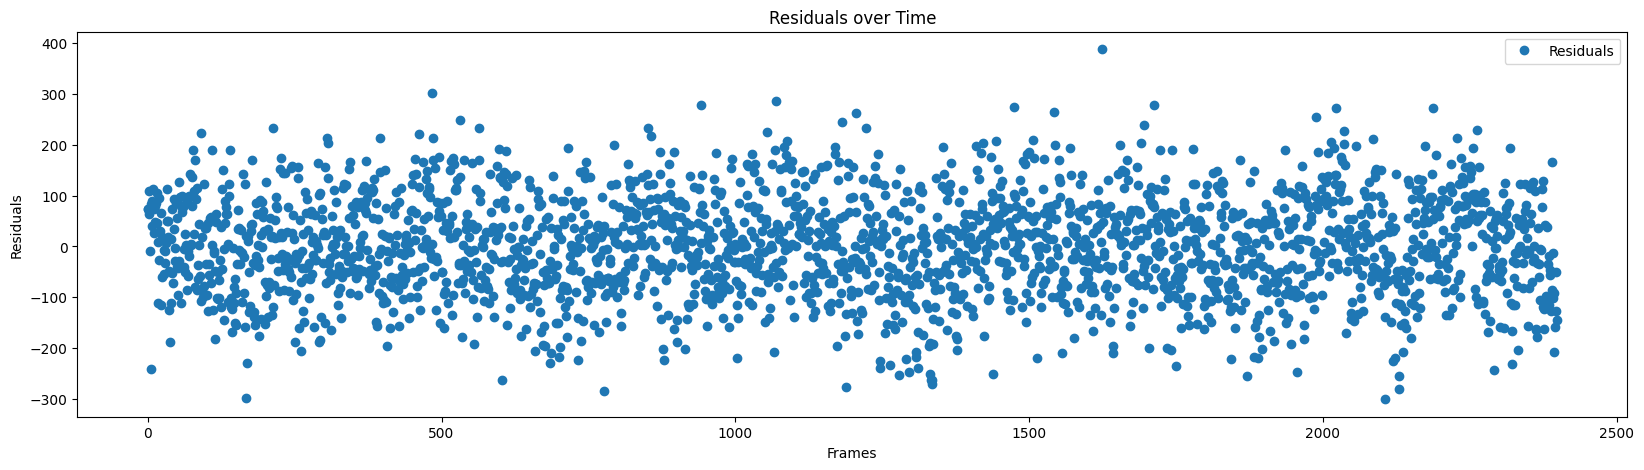

0.2
2335
2399


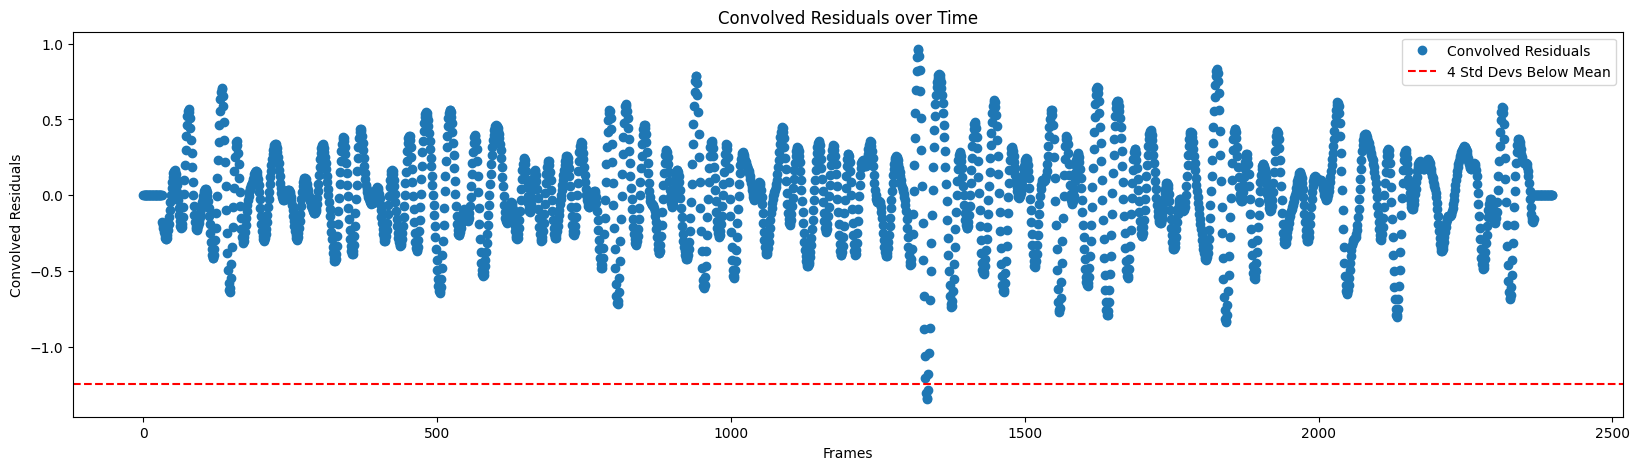

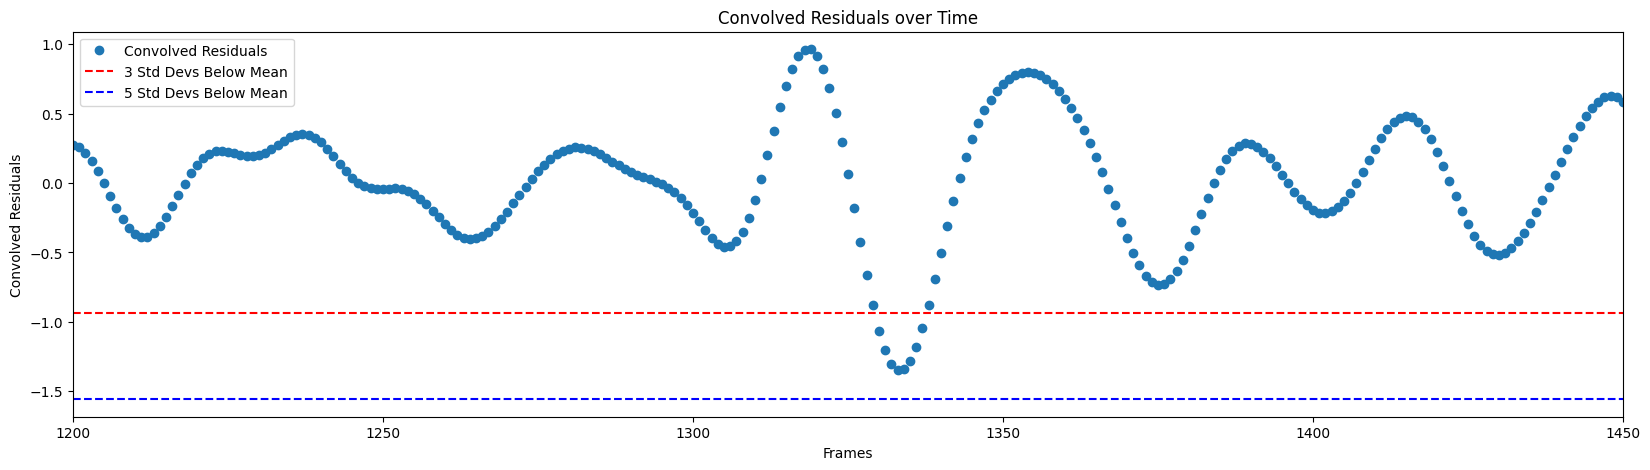

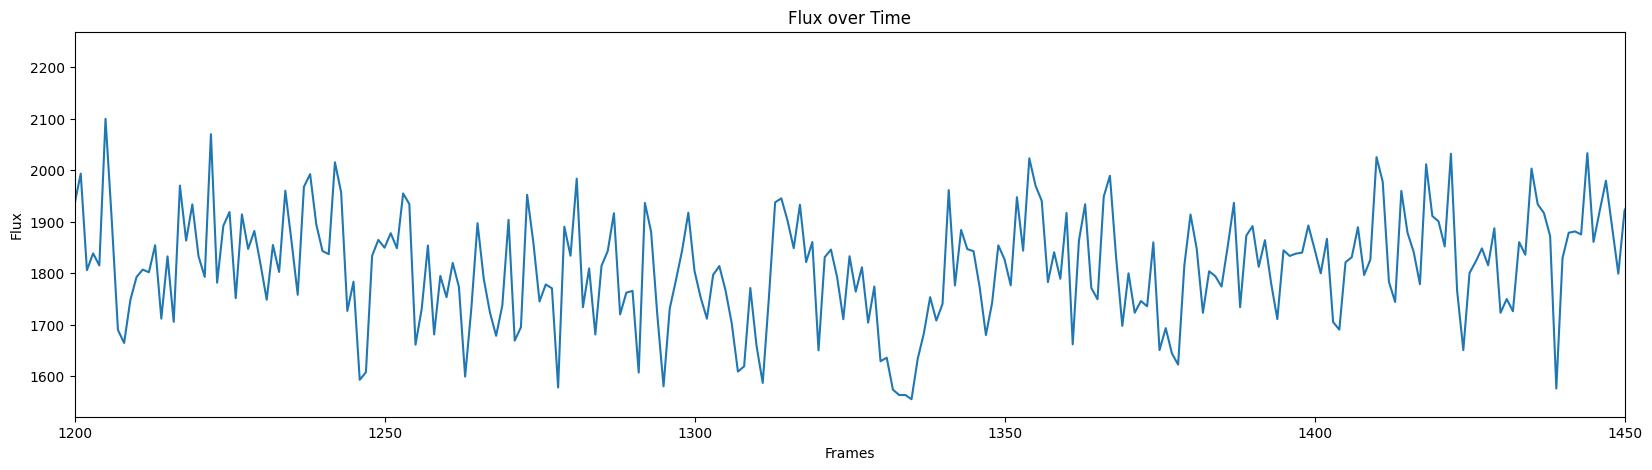

In [58]:
# first dimension is frame, second dim is star, third is [x, y, flux, time]
print(data[:, 0, 3])

time = data[:, 0, 3]
flux = data[:, 0, 2]

frames = range(len(flux))
# plot the flux over time
fig = plt.figure(figsize=(20, 5))
plt.plot(frames, flux, 'o')
plt.xlabel('Frames')
plt.ylabel('Flux')
plt.title('Flux over Time')
plt.show()

# mean smooth the flux using a filter
from scipy.ndimage import uniform_filter1d

smoothed_flux = uniform_filter1d(flux, size=40*10, mode='reflect')

fig = plt.figure(figsize=(20, 5))
plt.plot(frames, smoothed_flux, 'o')
plt.xlabel('Frames')
plt.ylabel('Smooth Flux')
plt.title('Smooth Flux over Time')
plt.show()

residuals = flux - smoothed_flux
fig = plt.figure(figsize=(20, 5))
plt.plot(frames, residuals, 'o', label='Residuals')
plt.xlabel('Frames')
plt.ylabel('Residuals')
plt.title('Residuals over Time')
plt.legend()
plt.show()

# convolve the residuals with a ricker wavelet
from scipy.signal import convolve
from astropy.convolution import RickerWavelet1DKernel



exposure_time = 0.025    # exposure length in seconds
expected_length = 8*exposure_time   # related to the characteristic scale length, length of signal to boost in convolution, may need tweaking/optimizing
print(round(expected_length, 3))
# expected_length = 0.15

kernel_frames = int(round(expected_length / exposure_time))   # width of kernel
ricker_kernel = RickerWavelet1DKernel(kernel_frames)          # generate kernel

conv = convolve(residuals, ricker_kernel, mode='valid')    #convolution of light curve with Ricker wavelet
# Calculate the number of zeros to add on each side
padding_length = (len(flux) - len(conv)) // 2

mean_conv = np.mean(conv)  # mean of the convolved residuals
std_conv = np.std(conv)  # standard deviation of the convolved residuals

# Create arrays of for padding
padding = np.ones(padding_length) * mean_conv

# Concatenate zeros to the beginning and end of the convolution result
conv_padded = np.concatenate((padding, conv, padding))
print(len(conv))
print(len(conv_padded))



fig = plt.figure(figsize=(20, 5))
plt.plot(frames, conv_padded, 'o', label='Convolved Residuals')
plt.xlabel('Frames')
plt.ylabel('Convolved Residuals')
plt.title('Convolved Residuals over Time')

# plot a horizontal line at 3 std devs below the mean of the convolved residuals
plt.axhline(mean_conv - 4*std_conv, color='red', linestyle='--', label='4 Std Devs Below Mean')
plt.legend()
plt.show()

fig = plt.figure(figsize=(20, 5))
plt.plot(frames, conv_padded, 'o', label='Convolved Residuals')
plt.xlabel('Frames')
plt.ylabel('Convolved Residuals')
plt.title('Convolved Residuals over Time')

# plot a horizontal line at 3 std devs below the mean of the convolved residuals
plt.axhline(mean_conv - 3*std_conv, color='red', linestyle='--', label='3 Std Devs Below Mean')
plt.axhline(mean_conv - 5*std_conv, color='blue', linestyle='--', label='5 Std Devs Below Mean')

plt.legend()
plt.xlim(1200, 1450)
plt.show()



fig = plt.figure(figsize=(20, 5))
plt.plot(frames, flux)
plt.xlabel('Frames')
plt.ylabel('Flux')
plt.title('Flux over Time')
plt.xlim(1200, 1450)
plt.show()




# Workshopping some functions

In [9]:
import numpy as np
import os
from datetime import datetime

def readRCD(filename):
    """
    Reads .rcd file
    
        Parameters:
            filename (Path): Path to .rcd file
            
        Returns:
            table (arr): Table with image pixel data
            timestamp (str): Timestamp of observation
    """

    ## Open .rcd file and extract the observation timestamp and data
    with open(filename, 'rb') as fid:
        # Timestamp
        fid.seek(152, 0)
        timestamp = fid.read(29).decode('utf-8')

        # Load data portion of file
        fid.seek(384, 0)
        table = np.fromfile(fid, dtype=np.uint8, count=12582912)

    return table, timestamp

# Test with the file
test = readRCD('D:\\Sensitivity_Measurements_2024\\20240729\\20240729_03.05.55.471\\Alt89.2_25ms-_0000010.rcd')

# Print image data shape and extracted timestamp
print(test[0].shape)
print("rcd time: ", test[1])

# Get the file creation or modification time from Windows
filename = 'D:\\Sensitivity_Measurements_2024\\20240729\\20240729_03.05.55.471\\Alt89.2_25ms-_0000010.rcd'

# Get the modification time of the file (in seconds since the epoch)
file_mod_time = os.path.getmtime(filename)

# Convert to datetime object in UTC
mod_time_utc = datetime.utcfromtimestamp(file_mod_time)

# Format the time in the required format: YYYY-MM-DDThh:mm:ss.dddddddddZ
formatted_mod_time = mod_time_utc.strftime('%Y-%m-%dT%H:%M:%S.') + f'{mod_time_utc.microsecond * 1000:09d}' 

# Print the Windows system modification time
print("Windows file modification time: ", formatted_mod_time)



(12582912,)
rcd time:  2016-00-00T00:35:03.747215425
Windows file modification time:  2024-07-29T03:05:55.790967000


new version

In [1]:
import numpy as np
import os
import datetime

def readRCD(filename):
    """
    Reads .rcd file and Windows file modification time.
    
        Parameters:
            filename (Path): Path to .rcd file
            
        Returns:
            table (arr): Table with image pixel data
            timestamp (str): Timestamp of observation
            file_mod_time (str): File modification time from the system in ISO format
    """

    ## Open .rcd file and extract the observation timestamp and data
    with open(filename, 'rb') as fid:
        # Timestamp from file
        fid.seek(152, 0)
        timestamp = fid.read(29).decode('utf-8')

        # Load data portion of file
        fid.seek(384, 0)
        table = np.fromfile(fid, dtype=np.uint8, count=12582912)

    # Get the file modification time from the Windows system
    file_mod_time_epoch = os.path.getmtime(filename)
    file_mod_time = datetime.datetime.fromtimestamp(file_mod_time_epoch, tz=datetime.timezone.utc)

    # Format the modification time without the 'Z'
    formatted_mod_time = file_mod_time.strftime('%Y-%m-%dT%H:%M:%S.') + f'{file_mod_time.microsecond * 1000:09d}'

    return table, timestamp, formatted_mod_time


# Test with the file
test = readRCD('D:\\Sensitivity_Measurements_2024\\20240729\\20240729_03.05.55.471\\Alt89.2_25ms-_0000010.rcd')

# Print image data shape and extracted timestamp
print(test[0].shape)
print("rcd time: ", test[1])
print("Windows file modification time: ", test[2])

print(type(test[1]))
print(type(test[2]))

(12582912,)
rcd time:  2016-00-00T00:35:03.747215425
Windows file modification time:  2024-07-29T03:05:55.790967000
<class 'str'>
<class 'str'>


new one works! just need to remove returning the original timestamp